# Tech Challenge - Fase 2 - Machine Learning and Time Series

## Cenário

Na Fase 2 do Tech Challenge, foi proposto um case utilizando dados do índice Ibovespa. O objetivo era desenvolver um modelo preditivo capaz de indicar se o índice irá fechar em alta ou em baixa no dia seguinte, com base no seu próprio histórico de cotações e variações.

Com os resultados obtidos, será desenvolvido um dashboard para monitoramento e apoio à tomada de decisão dos investidores internos, facilitando uma visão mais estratégica do comportamento do mercado.


# Índice Ibovespa

O Ibovespa é o principal índice da B3, a Bolsa de Valores do Brasil, e reflete o desempenho das ações das empresas com maior volume de negociação no mercado.

Na prática, ele funciona como uma média ponderada do desempenho das ações mais negociadas nos últimos meses. Quando se diz que o “Ibovespa subiu”, significa que, em média, essas ações se valorizaram, indicando um maior otimismo dos investidores.

# Dicionário de Dados

| Nome da Coluna | Descrição                                                                                  | Tipo de Dado       |
|----------------|---------------------------------------------------------------------------------------------|--------------------|
| Data           | A data da observação, no formato "DD/MM/AAAA".                                              | Texto (`object`)   |
| Ultimo         | O preço de fechamento do Ibovespa no dia.                                                   | Numérico (`float64`) |
| Abertura       | O preço de abertura do Ibovespa no dia.                                                     | Numérico (`float64`) |
| Maxima         | O preço máximo atingido pelo Ibovespa no dia.                                               | Numérico (`float64`) |
| Minima         | O preço mínimo atingido pelo Ibovespa no dia.                                               | Numérico (`float64`) |
| Volume         | O volume de negociações do dia. Valores com sufixos (ex: "B" para bilhões, "M" para milhões). | Texto (`object`)   |
| Variacao       | A variação percentual do Ibovespa no dia.                                                   | Texto (`object`)   |


# Case Final

Criar um modelo que preveja se o fechamento do IBOVESPA do dia seguinte será maior ou menor que o do dia atual, sendo:

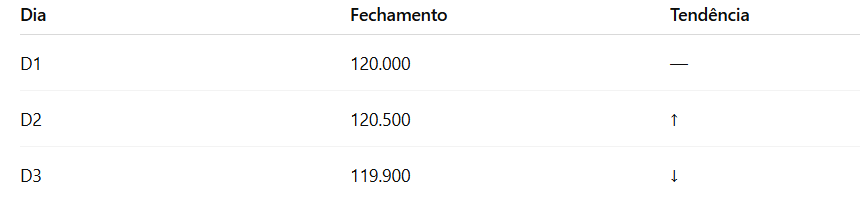

Onde deve prever a tendência (↑ ou ↓) com acuracidade mínima de 75% em um conjunto de teste, esse que contera o último mês (30 dias) de dados disponíveis.

# **Importação das Bibliotecas**


*   Importante instalar a biblioteca "ta" no ambiente que irá executar




In [8]:
# !pip install ta

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from ta.trend import SMAIndicator
from ta.volatility import BollingerBands
from ta.momentum import RSIIndicator
from ta.trend import MACD
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

# **Leitura e Tratamento do Dataset**

*   Considerando o período de 10 anos



In [10]:
dados = yf.download("^BVSP", period="10y", interval="1d")
dados = dados.dropna().reset_index()
dados = dados[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

C:\Users\Pedro\AppData\Local\Temp\ipykernel_29888\1015753301.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download("^BVSP", period="10y", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [11]:
dados.head()

Price,Date,Open,High,Low,Close,Volume
Ticker,,^BVSP,^BVSP,^BVSP,^BVSP,^BVSP
0,2016-04-13,52010.0,53844.0,52010.0,53150.0,6376500
1,2016-04-14,53150.0,53699.0,52242.0,52411.0,5492100
2,2016-04-15,52414.0,53390.0,52414.0,53228.0,5047800
3,2016-04-18,53229.0,53479.0,52305.0,52894.0,4385600
4,2016-04-19,52894.0,54054.0,52894.0,53710.0,5033900


In [12]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   (Date, )         2484 non-null   datetime64[ns]
 1   (Open, ^BVSP)    2484 non-null   float64       
 2   (High, ^BVSP)    2484 non-null   float64       
 3   (Low, ^BVSP)     2484 non-null   float64       
 4   (Close, ^BVSP)   2484 non-null   float64       
 5   (Volume, ^BVSP)  2484 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 116.6 KB


In [13]:
dados.rename(columns={'Date': 'data', 'Open': 'abertura', 'High': 'maxima', 'Low': 'minima', 'Close': 'fechamento', 'Volume': 'volume'}, inplace=True)
dados.head()

Price,data,abertura,maxima,minima,fechamento,volume
Ticker,,^BVSP,^BVSP,^BVSP,^BVSP,^BVSP
0,2016-04-13,52010.0,53844.0,52010.0,53150.0,6376500
1,2016-04-14,53150.0,53699.0,52242.0,52411.0,5492100
2,2016-04-15,52414.0,53390.0,52414.0,53228.0,5047800
3,2016-04-18,53229.0,53479.0,52305.0,52894.0,4385600
4,2016-04-19,52894.0,54054.0,52894.0,53710.0,5033900


In [14]:
# Verifica dados nulos
dados.isnull().sum()

Price       Ticker
data                  0
abertura    ^BVSP     0
maxima      ^BVSP     0
minima      ^BVSP     0
fechamento  ^BVSP     0
volume      ^BVSP     0
dtype: int64

### **Histograma de Distribuição de Frequência dos Fechamentos**

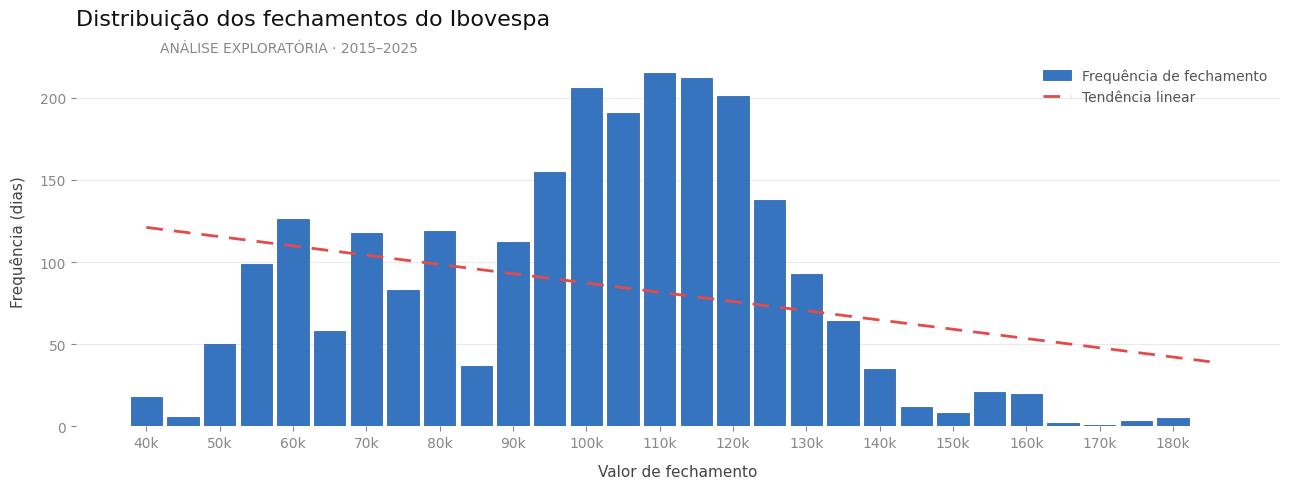

In [ ]:
# Dados
bins = list(range(40000, 190000, 5000))
labels = [f"{b//1000}k" for b in bins[:-1]]
freqs = [
    18, 6, 50, 99, 126, 58, 118, 83, 119, 37,
    112, 155, 206, 191, 215, 212, 201, 138, 93, 64,
    35, 12, 8, 21, 20, 2, 1, 3, 5, 0
]
x = np.arange(len(freqs))

# Tendência linear 
slope, intercept = np.polyfit(x, freqs, 1)
trend = slope * x + intercept

# Figura
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Barras
bar_colors = ["#3774c0"] * len(freqs)
bars = ax.bar(x, freqs, color=bar_colors, edgecolor="#2558a0",
              linewidth=0.5, width=0.85, zorder=2)

# Linha de tendência
ax.plot(x, trend, color="#e24b4a", linewidth=2,
        linestyle="--", dashes=(6, 4), zorder=3, label="Tendência linear")

# Eixos
ax.set_xticks(x[::2])
ax.set_xticklabels(labels[::2], fontsize=10, color="#666")
ax.set_ylabel("Frequência (dias)", fontsize=11, color="#444", labelpad=10)
ax.set_xlabel("Valor de fechamento", fontsize=11, color="#444", labelpad=10)
ax.tick_params(axis="y", colors="#888", labelsize=10)
ax.tick_params(axis="x", colors="#888", labelsize=10)

# Grid
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

# Cabeçalho
fig.text(0.07, 1.01, "ANÁLISE EXPLORATÓRIA · 2015–2025",
         fontsize=10, color="#888", ha="left", transform=ax.transAxes,
         fontweight="normal", style="normal")
ax.set_title("Distribuição dos fechamentos do Ibovespa",
             fontsize=16, fontweight="normal", color="#111",
             pad=22, loc="left")

# Legenda
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#3774c0", edgecolor="#2558a0", linewidth=0.5, label="Frequência de fechamento"),
    Line2D([0], [0], color="#e24b4a", linewidth=2, linestyle="--", dashes=(6, 4), label="Tendência linear"),
]
ax.legend(handles=legend_elements, fontsize=10, frameon=False,
          loc="upper right", labelcolor="#555")

plt.tight_layout()
plt.savefig("grafico_1_histograma.png", dpi=150, bbox_inches="tight")
plt.show()

# **Definição das Features e Criação do Target**

In [16]:
fechamento_series = dados['fechamento'].squeeze()

print(type(dados['fechamento']))
print(dados['fechamento'].shape)

<class 'pandas.core.frame.DataFrame'>
(2484, 1)


In [17]:
# Features e tendencia (target)

dados['var_dia'] = (dados['fechamento'] - dados['abertura']) / dados['abertura']
dados['MM20'] = dados['fechamento'].rolling(window=20).mean()
dados['sma_5'] = SMAIndicator(close=fechamento_series, window=5).sma_indicator()
dados['sma_10'] = SMAIndicator(close=fechamento_series, window=10).sma_indicator()
dados['rsi_7'] = RSIIndicator(close=fechamento_series, window=7).rsi()


dados['tendencia'] = np.where(dados['fechamento'].shift(-1) < dados['fechamento'], 1, 0)


dados.dropna(inplace=True)

dados = dados.sort_values('data')

dados.head()

Price,data,abertura,maxima,minima,fechamento,volume,var_dia,MM20,sma_5,sma_10,rsi_7,tendencia
Ticker,,^BVSP,^BVSP,^BVSP,^BVSP,^BVSP,,,,,,
19,2016-05-11,53072.0,53976.0,52736.0,52764.0,4350000,-0.005803,52908.35,52042.8,52681.2,51.529507,0
20,2016-05-12,52765.0,53703.0,52424.0,53241.0,4630400,0.009021,52912.90,52356.8,52574.1,56.324855,1
21,2016-05-13,53236.0,53250.0,51366.0,51804.0,4314300,-0.026899,52882.55,52374.0,52363.4,41.792741,1
22,2016-05-16,51803.0,52305.0,51585.0,51803.0,3529500,0.000000,52811.30,52536.6,52187.5,41.783989,1
23,2016-05-17,51795.0,51946.0,50689.0,50839.0,3871100,-0.018457,52708.55,52090.2,52045.4,33.818596,1


### **Criação de Lags**

In [18]:
qtd_lags = 10
for i in range(1, qtd_lags + 1):
    dados[f"lag_{i}"] = dados["fechamento"].pct_change(i)

# Limpeza dos NaNs
dados.dropna(inplace=True)


In [19]:
dados.tail()

Price,data,abertura,maxima,minima,fechamento,volume,var_dia,MM20,sma_5,sma_10,...,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
Ticker,,^BVSP,^BVSP,^BVSP,^BVSP,^BVSP,,,,,...,,,,,,,,,,
2479,2026-04-07,188162.000,188259.000000,185885.000000,188259.000000,8753200,0.000516,182866.300000,187977.600000,185462.500000,...,0.000516,0.001101,0.001628,0.004252,0.031477,0.036914,0.030241,0.015289,0.031505,0.034777
2480,2026-04-08,188261.000,193759.000000,188260.000000,192201.000000,12594000,0.020928,183304.000000,188925.400000,186431.700000,...,0.020939,0.021466,0.022063,0.022601,0.025280,0.053075,0.058626,0.051813,0.036549,0.053104
2481,2026-04-09,192206.000,195514.000000,192206.000000,195129.000000,9382900,0.015208,183862.000000,190360.600000,187402.200000,...,0.015234,0.036492,0.037027,0.037633,0.038180,0.040899,0.069118,0.074753,0.067837,0.052340
2482,2026-04-10,195130.000,197554.000000,195129.000000,197324.000000,9661000,0.011244,184763.950000,192215.000000,188861.300000,...,0.011249,0.026654,0.048152,0.048692,0.049306,0.049858,0.052608,0.081144,0.086843,0.079849
2483,2026-04-13,197323.875,198173.390625,196222.859375,198000.703125,0,0.003430,185781.335156,194182.740625,190505.670313,...,0.003429,0.014717,0.030175,0.051746,0.052288,0.052904,0.053459,0.056218,0.084852,0.090570


## **Gráfico de Linha - Acompanhamento da Média de Fechamento Anual (BVSP)**

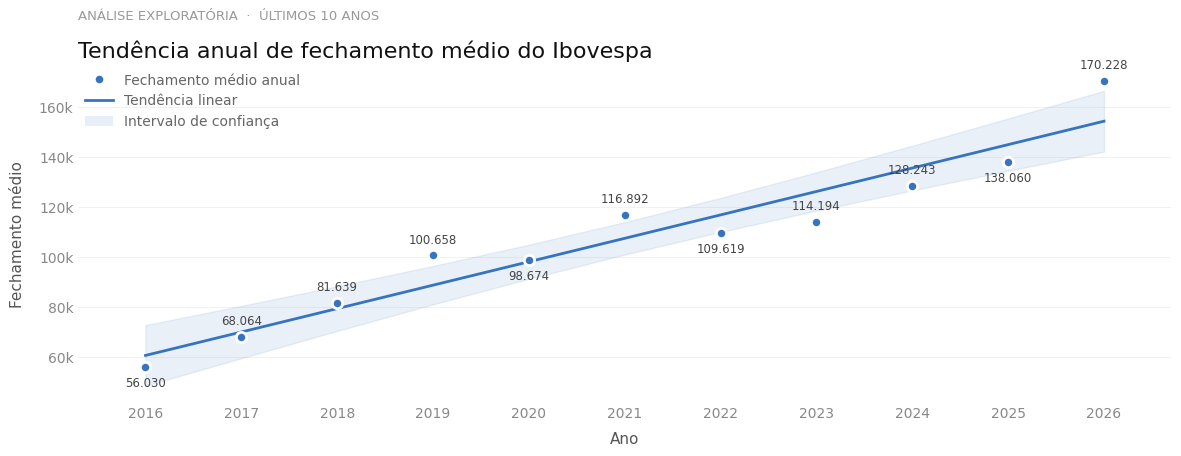

In [48]:
# Dados
years  = np.array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])
values = np.array([56030, 68064, 81639, 100658, 98674, 116892,
                   109619, 114194, 128243, 138060, 170228], dtype=float)

# Regressão + IC 95%
slope, intercept, *_ = stats.linregress(years, values)
trend = slope * years + intercept

n      = len(years)
t_crit = 2.262
x_mean = years.mean()
ss_xx  = ((years - x_mean) ** 2).sum()
res_se = np.sqrt(((values - trend) ** 2).sum() / (n - 2))
ci     = t_crit * res_se * np.sqrt(1/n + (years - x_mean)**2 / ss_xx)

# Figura
fig, ax = plt.subplots(figsize=(12, 4.8))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

BLUE = "#3774c0"

# Faixa de confiança
ax.fill_between(years, trend - ci, trend + ci,
                color=BLUE, alpha=0.10, zorder=1)

# Linha de tendência
ax.plot(years, trend, color=BLUE, linewidth=2, zorder=2)

# Pontos
ax.scatter(years, values, color=BLUE, s=55, zorder=4,
           edgecolors="#ffffff", linewidths=2.0)

# Rótulos dos pontos
label_offsets = {
    2016: (0, -14),
    2017: (0,   9),
    2018: (0,   9),
    2019: (0,   9),
    2020: (0, -14),
    2021: (0,   9),
    2022: (0, -14),
    2023: (0,   9),
    2024: (0,   9),
    2025: (0,  -14),
    2026: (0,   9),
}
for y, v in zip(years, values):
    dx, dy = label_offsets.get(int(y), (0, 9))
    ax.annotate(f"{int(v):,}".replace(",", "."),
                xy=(y, v), xytext=(dx, dy),
                textcoords="offset points",
                ha="center", fontsize=8.5, color="#444444")

# Eixos
ax.set_xticks(years)
ax.set_xticklabels([str(int(y)) for y in years], fontsize=10, color="#888888")
ax.set_xlim(years[0] - 0.7, years[-1] + 0.7)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax.tick_params(axis="y", colors="#888888", labelsize=10)
ax.set_ylabel("Fechamento médio", fontsize=11, color="#555555", labelpad=10)
ax.set_xlabel("Ano", fontsize=11, color="#555555", labelpad=8)

# Grid e spines
ax.yaxis.grid(True, color="#ebebeb", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", length=0)

# Cabeçalho
ax.text(0.0, 1.13, "ANÁLISE EXPLORATÓRIA  ·  ÚLTIMOS 10 ANOS",
        transform=ax.transAxes, fontsize=9.5, color="#999999",
        ha="left", va="bottom")
ax.set_title("Tendência anual de fechamento médio do Ibovespa",
             fontsize=16, fontweight="normal", color="#111111",
             pad=6, loc="left")

# Legenda
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=BLUE,
           markeredgecolor="#ffffff", markeredgewidth=1.5,
           markersize=7, label="Fechamento médio anual"),
    Line2D([0], [0], color=BLUE, linewidth=2, label="Tendência linear"),
    Patch(facecolor=BLUE, alpha=0.12, edgecolor="none",
          label="Intervalo de confiança"),
]
ax.legend(handles=legend_handles, fontsize=10, frameon=False,
          loc="upper left", labelcolor="#666666",
          handlelength=2.0, borderpad=0)

plt.tight_layout(pad=1.4)
plt.savefig("grafico_2_tendencia_anual.png", dpi=150, bbox_inches="tight",
            facecolor="#ffffff")
plt.show()

# **Separando Modelos de treino e teste**

In [21]:
print("Data Mínima:")
display(dados['data'].min())

print("\nData Máxima:")
display(dados['data'].max())

Data Mínima:


Timestamp('2016-05-25 00:00:00')


Data Máxima:


Timestamp('2026-04-13 00:00:00')

In [22]:
treino = dados[(dados['data'] > "2015-09-01") & (dados['data'] < "2025-06-18")].copy()
teste  = dados[(dados['data'] > "2025-06-17") & (dados['data'] < "2025-07-31")].copy()

features = ['abertura', 'maxima', 'minima', 'var_dia','MM20', 'rsi_7']


x_train = treino[features]
y_train = treino['tendencia']
x_test = teste[features]
y_test = teste['tendencia']

### Validação das linhas consideradas nos modelos de treino e teste

In [23]:
print("Linhas no teste:", teste.shape[0])
print("\nLinhas no treino:", treino.shape[0])


Linhas no teste: 30

Linhas no treino: 2250


### **Dados Correlações - Features x Target**

In [24]:
dados_correlacoes = dados[features + ['tendencia']].corr()
print(dados_correlacoes['tendencia'].sort_values())


Price      Ticker
rsi_7                0.000835
abertura   ^BVSP     0.023792
maxima     ^BVSP     0.024201
minima     ^BVSP     0.025266
MM20                 0.027485
var_dia              0.049575
tendencia            1.000000
Name: tendencia, dtype: float64


### **Random Forest**

In [25]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=7
)

modelo_rf.fit(x_train, y_train)
y_pred_rf = modelo_rf.predict(x_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, modelo_rf.predict_proba(x_test)[:, 1])

print(f"Acurácia (Random Forest): {acc_rf:.2%}")
print(f"ROC AUC: {roc_rf:.3f}")

Acurácia (Random Forest): 73.33%
ROC AUC: 0.685


### **XGboost**

In [26]:
modelo_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
modelo_xgb.fit(x_train, y_train)

y_pred = modelo_xgb.predict(x_test)
acuracia = accuracy_score(y_test, y_pred)
roc_score = roc_auc_score(y_test, modelo_xgb.predict_proba(x_test)[:, 1])

print(f"Acurácia: {acuracia:.2%}")
print(f"ROC AUC: {roc_score:.3f}")

Acurácia: 66.67%
ROC AUC: 0.639


# **Matriz Confusão - Modelo XGboost**

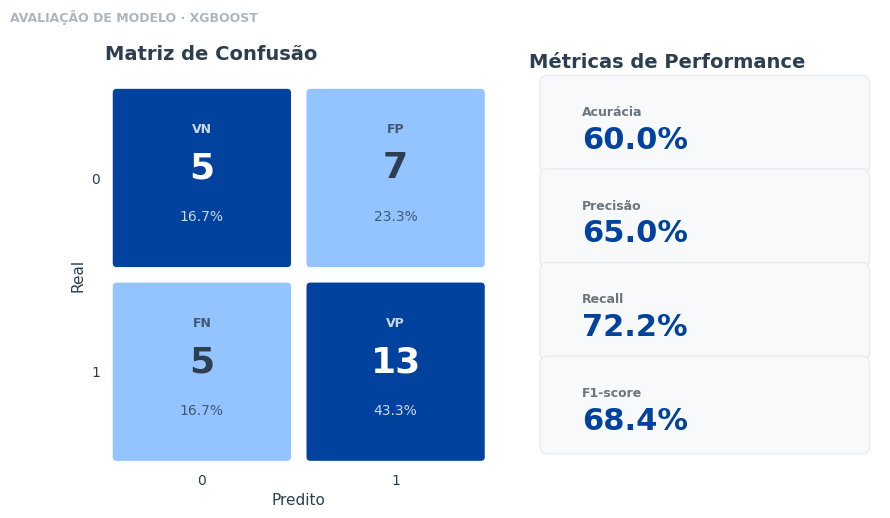

In [61]:
# Dados
cm     = np.array([[5, 7], [5, 13]])
labels = ["0", "1"]
cell_labels = [["VN", "FP"], ["FN", "VP"]]

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
total = cm.sum()

accuracy  = (tp + tn) / total
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * tp / (2 * tp + fp + fn)

# Cores Azuis
COLOR_MAIN_BLUE = "#00429d" # Azul profundo para acertos (VP/VN)
COLOR_SOFT_BLUE = "#93c4ff" # Azul claro para erros (FP/FN)
COLOR_BG        = "#ffffff" 
COLOR_TEXT_DARK = "#2c3e50"
COLOR_METRIC_BG = "#f8f9fa"

def get_blue_theme(row, col):
    # Se real == previsto (diagonal principal), azul forte. Caso contrário, azul claro.
    return COLOR_MAIN_BLUE if row == col else COLOR_SOFT_BLUE

# Figura
fig = plt.figure(figsize=(10, 5.5))
fig.patch.set_facecolor(COLOR_BG)

gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 0.95], wspace=0.1)
ax_cm  = fig.add_subplot(gs[0])
ax_met = fig.add_subplot(gs[1])

# Matriz de Confusão 
ax_cm.set_facecolor(COLOR_BG)
ax_cm.set_aspect("equal")
ax_cm.set_xlim(0, 2)
ax_cm.set_ylim(0, 2)

for i in range(2):
    for j in range(2):
        val   = cm[i, j]
        pct   = val / total * 100
        color = get_blue_theme(i, j)
        yt    = 1 - i 

        rect = mpatches.FancyBboxPatch(
            (j + 0.06, yt + 0.06), 0.88, 0.88,
            boxstyle="round,pad=0.02",
            facecolor=color, edgecolor="none", zorder=2
        )
        ax_cm.add_patch(rect)

        cx, cy = j + 0.5, yt + 0.5
        # Texto branco para o azul escuro, cinza escuro para o azul claro (contraste)
        txt_color = "white" if i == j else COLOR_TEXT_DARK
        
        ax_cm.text(cx, cy + 0.25, cell_labels[i][j], ha="center", va="center", 
                   fontsize=9, color=txt_color, alpha=0.8, fontweight="bold")
        ax_cm.text(cx, cy + 0.05, str(val), ha="center", va="center", 
                   fontsize=26, color=txt_color, fontweight="700")
        ax_cm.text(cx, cy - 0.20, f"{pct:.1f}%", ha="center", va="center", 
                   fontsize=10, color=txt_color, alpha=0.8)

# Eixos da Matriz
ax_cm.set_xticks([0.5, 1.5])
ax_cm.set_yticks([0.5, 1.5])
ax_cm.set_xticklabels(labels, fontsize=10, color=COLOR_TEXT_DARK)
ax_cm.set_yticklabels(["1", "0"], fontsize=10, color=COLOR_TEXT_DARK)
ax_cm.set_xlabel("Predito", fontsize=11, color=COLOR_TEXT_DARK, fontweight="500")
ax_cm.set_ylabel("Real", fontsize=11, color=COLOR_TEXT_DARK, fontweight="500")
for spine in ax_cm.spines.values(): spine.set_visible(False)
ax_cm.tick_params(length=0)
ax_cm.set_title("Matriz de Confusão", fontsize=14, fontweight="700", color=COLOR_TEXT_DARK, loc="left", pad=15)

# Métricas
ax_met.axis("off")
metrics = [
    ("Acurácia", f"{accuracy*100:.1f}%"),
    ("Precisão", f"{precision*100:.1f}%"),
    ("Recall",    f"{recall*100:.1f}%"),
    ("F1-score",  f"{f1*100:.1f}%"),
]

for idx, (name, val) in enumerate(metrics):
    y0 = 0.85 - idx * 0.23
    rect = mpatches.FancyBboxPatch(
        (0.05, y0 - 0.08), 0.9, 0.20,
        boxstyle="round,pad=0.02",
        facecolor=COLOR_METRIC_BG, edgecolor="#e9ecef", linewidth=1,
        transform=ax_met.transAxes, zorder=1
    )
    ax_met.add_patch(rect)
    ax_met.text(0.15, y0 + 0.04, name, fontsize=9, color="#6c757d", 
                transform=ax_met.transAxes, fontweight="600")
    ax_met.text(0.15, y0 - 0.04, val, fontsize=22, color=COLOR_MAIN_BLUE, 
                transform=ax_met.transAxes, fontweight="700")

ax_met.set_title("Métricas de Performance", fontsize=14, fontweight="700", 
                 color=COLOR_TEXT_DARK, loc="left", pad=15, transform=ax_met.transAxes)

# Subtítulo
fig.text(0.03, 0.94, "AVALIAÇÃO DE MODELO · XGBOOST", fontsize=9, color="#adb5bd", fontweight="600")

plt.subplots_adjust(top=0.85)
plt.show()

# **Importância das features utilizadas**

In [28]:
print(classification_report(y_test, y_pred))

importances = modelo_xgb.feature_importances_
importancias_df = pd.DataFrame({'feature': features, 'importance': importances})
importancias_df.sort_values(by='importance', ascending=False, inplace=True)

              precision    recall  f1-score   support

           0       0.62      0.42      0.50        12
           1       0.68      0.83      0.75        18

    accuracy                           0.67        30
   macro avg       0.65      0.62      0.62        30
weighted avg       0.66      0.67      0.65        30



# **Importância das Variáveis**

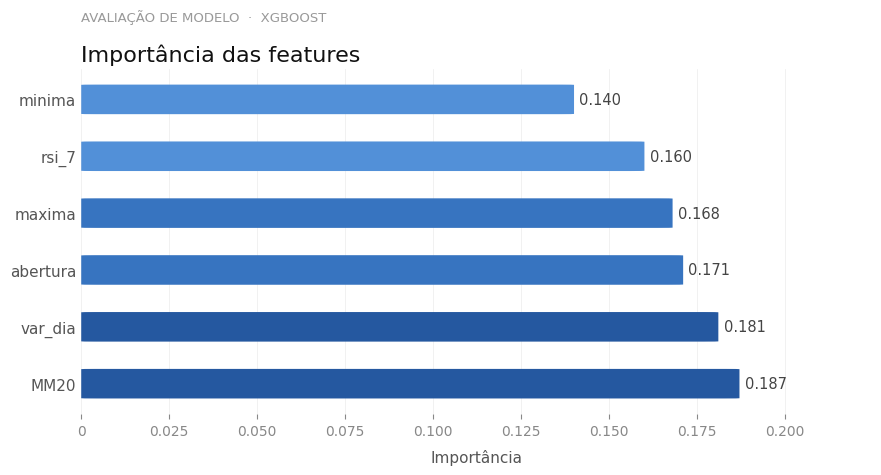

In [ ]:
# Dados (ordenados do menor para o maior)
features   = ["minima", "rsi_7", "maxima", "abertura", "var_dia", "MM20"]
importance = [0.140,     0.160,   0.168,    0.171,      0.181,     0.187]

x = np.array(importance)
y = np.arange(len(features))
max_val = max(importance)

# Intensidade da cor proporcional ao valor
def bar_color(val, max_val):
    ratio = val / max_val
    if ratio > 0.95:
        return "#2558a0"
    elif ratio > 0.88:
        return "#3774c0"
    else:
        return "#5290d8"

colors = [bar_color(v, max_val) for v in importance]

# Figura
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Barras horizontais com bordas arredondadas (simuladas via barh + clip)
bars = ax.barh(y, x, color=colors, height=0.55, zorder=2)

# Arredondar as pontas das barras manualmente
for bar, color in zip(bars, colors):
    bar.set_linewidth(0)
    w = bar.get_width()
    h = bar.get_height()
    yb = bar.get_y()
    radius = h * 0.35
    fancy = mpatches.FancyBboxPatch(
        (0, yb), w, h,
        boxstyle=f"round,pad=0,rounding_size={radius}",
        facecolor=color, edgecolor="none", zorder=2
    )
    ax.add_patch(fancy)
    bar.set_visible(False)

# Rótulos de valor no final de cada barra
for val, ypos in zip(importance, y):
    ax.text(val + 0.002, ypos, f"{val:.3f}",
            va="center", ha="left", fontsize=10, color="#444")

# Eixos
ax.set_yticks(y)
ax.set_yticklabels(features, fontsize=11, color="#555")
ax.set_xlabel("Importância", fontsize=11, color="#444", labelpad=10)
ax.set_xlim(0, max_val * 1.18)
ax.tick_params(axis="x", colors="#888", labelsize=10)
ax.tick_params(axis="y", length=0)

# Grid vertical sutil
ax.xaxis.grid(True, color="#e0e0e0", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

# Cabeçalho
fig.text(0.0, 1.02, "AVALIAÇÃO DE MODELO · XGBOOST",
         fontsize=10, color="#888", ha="left", transform=ax.transAxes)
ax.set_title("Importância das features",
             fontsize=16, fontweight="normal", color="#111",
             pad=22, loc="left")

plt.tight_layout()
plt.savefig("grafico_4_importancia_features.png", dpi=150, bbox_inches="tight")
plt.show()